In [75]:
import pandas as pd

In [76]:
df=pd.read_csv('pd_speech_features.csv')

In [77]:
df

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,250,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,...,3.0706,3.0190,3.1212,2.4921,3.5844,3.5400,3.3805,3.2003,6.8671,0
752,250,0,0.16084,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,...,1.9704,1.7451,1.8277,2.4976,5.2981,4.2616,6.3042,10.9058,28.4170,0
753,251,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,...,51.5607,44.4641,26.1586,6.3076,2.8601,2.5361,3.5377,3.3545,5.0424,0
754,251,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,...,19.1607,12.8312,8.9434,2.2044,1.9496,1.9664,2.6801,2.8332,3.7131,0


In [78]:
df = df.drop(columns=['id'])

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 754 entries, gender to class
dtypes: float64(749), int64(5)
memory usage: 4.3 MB


In [80]:
total_nulls = df.isnull().sum().sum()
print(total_nulls)

0


In [81]:
import pandas as pd
from scipy.stats import shapiro

# Select numeric columns only
numeric_cols = df.select_dtypes(include='number').columns

normality_results = {}

for col in numeric_cols:
    stat, p = shapiro(df[col].dropna())
    if p > 0.05:
        normality_results[col] = 'Normal'
    else:
        normality_results[col] = 'Not Normal'

# Display results
for col, result in normality_results.items():
    print(f"{col}: {result}")


gender: Not Normal
PPE: Not Normal
DFA: Not Normal
RPDE: Not Normal
numPulses: Not Normal
numPeriodsPulses: Not Normal
meanPeriodPulses: Not Normal
stdDevPeriodPulses: Not Normal
locPctJitter: Not Normal
locAbsJitter: Not Normal
rapJitter: Not Normal
ppq5Jitter: Not Normal
ddpJitter: Not Normal
locShimmer: Not Normal
locDbShimmer: Not Normal
apq3Shimmer: Not Normal
apq5Shimmer: Not Normal
apq11Shimmer: Not Normal
ddaShimmer: Not Normal
meanAutoCorrHarmonicity: Not Normal
meanNoiseToHarmHarmonicity: Not Normal
meanHarmToNoiseHarmonicity: Not Normal
minIntensity: Not Normal
maxIntensity: Not Normal
meanIntensity: Not Normal
f1: Normal
f2: Not Normal
f3: Not Normal
f4: Normal
b1: Not Normal
b2: Not Normal
b3: Not Normal
b4: Not Normal
GQ_prc5_95: Not Normal
GQ_std_cycle_open: Not Normal
GQ_std_cycle_closed: Not Normal
GNE_mean: Not Normal
GNE_std: Not Normal
GNE_SNR_TKEO: Not Normal
GNE_SNR_SEO: Not Normal
GNE_NSR_TKEO: Not Normal
GNE_NSR_SEO: Not Normal
VFER_mean: Not Normal
VFER_std: No

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [82]:
import pandas as pd


numeric_cols = df.select_dtypes(include='number').columns

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = outliers.shape[0]

print("Outlier counts per numeric column:")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")


Outlier counts per numeric column:
gender: 0
PPE: 108
DFA: 0
RPDE: 0
numPulses: 11
numPeriodsPulses: 10
meanPeriodPulses: 10
stdDevPeriodPulses: 135
locPctJitter: 71
locAbsJitter: 72
rapJitter: 71
ppq5Jitter: 61
ddpJitter: 72
locShimmer: 29
locDbShimmer: 26
apq3Shimmer: 28
apq5Shimmer: 32
apq11Shimmer: 21
ddaShimmer: 28
meanAutoCorrHarmonicity: 87
meanNoiseToHarmHarmonicity: 96
meanHarmToNoiseHarmonicity: 18
minIntensity: 38
maxIntensity: 39
meanIntensity: 35
f1: 5
f2: 9
f3: 30
f4: 1
b1: 53
b2: 75
b3: 98
b4: 72
GQ_prc5_95: 34
GQ_std_cycle_open: 32
GQ_std_cycle_closed: 85
GNE_mean: 35
GNE_std: 41
GNE_SNR_TKEO: 29
GNE_SNR_SEO: 25
GNE_NSR_TKEO: 24
GNE_NSR_SEO: 39
VFER_mean: 70
VFER_std: 65
VFER_entropy: 72
VFER_SNR_TKEO: 61
VFER_SNR_SEO: 62
VFER_NSR_TKEO: 3
VFER_NSR_SEO: 3
IMF_SNR_SEO: 92
IMF_SNR_TKEO: 51
IMF_SNR_entropy: 41
IMF_NSR_SEO: 6
IMF_NSR_TKEO: 59
IMF_NSR_entropy: 7
mean_Log_energy: 18
mean_MFCC_0th_coef: 23
mean_MFCC_1st_coef: 14
mean_MFCC_2nd_coef: 4
mean_MFCC_3rd_coef: 2
mean_

In [83]:
import pandas as pd
from scipy.stats.mstats import winsorize

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    # Determine lower and upper limits using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply Winsorization in-place
    df[col] = winsorize(df[col], limits=(
        (df[col] < lower_bound).mean(),
        (df[col] > upper_bound).mean()
    ))


In [84]:

unique_classes = df['class'].unique()
print(unique_classes)


class_counts = df['class'].value_counts()
print(class_counts)


[1 0]
class
1    564
0    192
Name: count, dtype: int64


In [85]:
import pandas as pd
from scipy.stats import f_oneway


numeric_cols = df.select_dtypes(include='number').columns
target_col = 'class'

insignificant_cols = []


for col in numeric_cols:
    groups = [df[col][df[target_col] == cls] for cls in df[target_col].unique()]
    stat, p = f_oneway(*groups)
    if p > 0.05:
        insignificant_cols.append(col)
    print(f"{col}: p-value = {p:.5f}, {'Significant' if p <= 0.05 else 'Not Significant'}")


df.drop(columns=insignificant_cols, inplace=True)

print("\nRemoved insignificant columns:", insignificant_cols)


gender: p-value = 0.00000, Significant
PPE: p-value = 0.00077, Significant
DFA: p-value = 0.00000, Significant
RPDE: p-value = 0.00000, Significant
numPulses: p-value = 0.00000, Significant
numPeriodsPulses: p-value = 0.00000, Significant
meanPeriodPulses: p-value = 0.00000, Significant
stdDevPeriodPulses: p-value = 0.00027, Significant
locPctJitter: p-value = 0.00000, Significant
locAbsJitter: p-value = 0.00000, Significant
rapJitter: p-value = 0.00000, Significant
ppq5Jitter: p-value = 0.00000, Significant
ddpJitter: p-value = 0.00000, Significant
locShimmer: p-value = 0.00000, Significant
locDbShimmer: p-value = 0.00000, Significant
apq3Shimmer: p-value = 0.00019, Significant
apq5Shimmer: p-value = 0.00001, Significant
apq11Shimmer: p-value = 0.00000, Significant
ddaShimmer: p-value = 0.00019, Significant
meanAutoCorrHarmonicity: p-value = 0.00000, Significant
meanNoiseToHarmHarmonicity: p-value = 0.00000, Significant
meanHarmToNoiseHarmonicity: p-value = 0.00000, Significant
minInt

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [86]:
df

,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,locAbsJitter,...,tqwt_kurtosisValue_dec_25,tqwt_kurtosisValue_dec_26,tqwt_kurtosisValue_dec_27,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,0.000018,...,2.0062,1.6058,1.5466,1.5620,2.6445,4.4625,2.6202,3.0004,18.9405,1
1,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,0.000016,...,2.0470,1.5772,1.5530,1.5589,3.6107,9.5082,6.5245,6.3431,45.1780,1
2,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,0.000015,...,3.0664,1.5921,1.5399,1.5643,2.3308,4.8066,2.9199,3.1495,4.7666,1
3,0,0.65734,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,0.000038,...,1.9120,1.8829,6.9761,3.7805,3.5664,4.6857,4.8460,6.2650,4.0603,1
4,0,0.65734,0.79782,0.53028,236,235,0.008162,0.000352,0.00483,0.000038,...,1.7577,1.8821,7.8832,6.1727,5.8416,11.6891,8.2103,5.0559,6.1164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,0,0.80903,0.56355,0.28385,417,416,0.004627,0.000052,0.00064,0.000003,...,1.7601,5.0509,3.4394,3.0706,3.0190,3.5400,3.3805,3.2003,6.8671,0
752,0,0.65734,0.56499,0.59194,415,413,0.004550,0.000220,0.00143,0.000006,...,3.0664,5.0509,19.6733,1.9704,1.7451,4.2616,6.3042,10.9058,28.4170,0
753,0,0.88389,0.72335,0.46815,381,380,0.005069,0.000103,0.00076,0.000004,...,1.6380,2.3279,27.3322,51.5607,44.4641,2.5361,3.5377,3.3545,5.0424,0
754,0,0.83782,0.74890,0.49823,340,339,0.005679,0.000055,0.00092,0.000005,...,1.5692,1.6052,5.4425,19.1607,12.8312,1.9664,2.6801,2.8332,3.7131,0


**select top 50 features with select k best and anova f**

In [87]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif


X = df.drop(columns=['class'])
y = df['class']


selector = SelectKBest(score_func=f_classif, k=100)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]


feature_scores = pd.Series(selector.scores_[selector.get_support()], index=selected_features)
feature_scores = feature_scores.sort_values(ascending=False)

print("Top 80 features with ANOVA F-scores:")
print(feature_scores)

df = df[selected_features.tolist() + ['class']]


Top 80 features with ANOVA F-scores:
tqwt_stdValue_dec_12           178.769799
tqwt_entropy_shannon_dec_12    175.407990
tqwt_TKEO_mean_dec_12          171.703325
tqwt_TKEO_std_dec_12           165.464874
tqwt_minValue_dec_12           143.528230
                                  ...    
app_TKEO_std_5_coef             70.752484
tqwt_entropy_log_dec_10         70.263670
VFER_entropy                    70.167489
app_TKEO_std_6_coef             69.935725
tqwt_TKEO_std_dec_8             68.755442
Length: 100, dtype: float64


In [88]:
df.head(5)

,DFA,minIntensity,f1,VFER_entropy,mean_MFCC_2nd_coef,std_Log_energy,std_delta_log_energy,std_6th_delta,std_7th_delta,std_8th_delta,...,tqwt_minValue_dec_14,tqwt_maxValue_dec_10,tqwt_maxValue_dec_11,tqwt_maxValue_dec_12,tqwt_maxValue_dec_13,tqwt_maxValue_dec_14,tqwt_kurtosisValue_dec_18,tqwt_kurtosisValue_dec_20,tqwt_kurtosisValue_dec_27,class
0,0.71826,69.997496,539.342735,0.83621,2.4874,0.34158,0.049933,0.028830,0.042253,0.028115,...,-0.108390,0.025222,0.022796,0.024286,0.048924,0.105750,2.8531,2.1550,1.5466,1
1,0.69481,67.415903,564.363615,1.04550,2.8986,0.22994,0.037774,0.050259,0.037071,0.022166,...,-0.101340,0.063234,0.080975,0.099695,0.112210,0.121580,2.0585,2.2061,1.5530,1
2,0.67604,62.661706,548.444604,0.63668,3.2208,0.52574,0.080533,0.054611,0.051511,0.032326,...,-0.081836,0.011110,0.013810,0.026241,0.039886,0.081818,3.4851,2.0427,1.5399,1
3,0.79672,76.306989,819.529588,0.45452,3.1023,0.21182,0.039296,0.035774,0.035142,0.032577,...,-0.586380,0.117990,0.111290,0.122970,0.273530,0.567740,3.9604,2.0362,6.9761,1
4,0.79782,76.645686,846.796144,0.71541,2.9451,0.17405,0.028652,0.029721,0.033943,0.031989,...,-0.505800,0.072172,0.086621,0.102950,0.235860,0.567490,3.4869,2.1073,7.8832,1


In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split


X = df.drop(columns=['class'])
y = df['class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)


Train set shape: (604, 101)
Test set shape: (152, 101)


In [90]:

unique_classes = train_df['class'].unique()
print("Unique classes:", unique_classes)

# Count of each class
class_counts = train_df['class'].value_counts()
print("\nClass distribution in train set:")
print(class_counts)


Unique classes: [1 0]

Class distribution in train set:
class
1    451
0    153
Name: count, dtype: int64


**GAN FOR DATA BALANCING**

In [91]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Separate features and target
X = train_df.drop('class', axis=1).values
y = train_df['class']

target_classes = y.unique()
desired_samples = 1000  # target per class

# Build GAN components
def build_generator():
    model = Sequential()
    model.add(Dense(128, activation='relu', input_dim=100))
    model.add(Dense(X.shape[1], activation='sigmoid'))
    return model

def build_discriminator():
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X.shape[1],)))
    model.add(Dense(1, activation='sigmoid'))
    return model

def build_gan(generator, discriminator):
    discriminator.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    discriminator.trainable = False
    gan_input = Sequential()
    gan_input.add(generator)
    gan_input.add(discriminator)
    gan_input.compile(loss='binary_crossentropy', optimizer=Adam())
    return gan_input

# Initialize models
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

# Train GAN
for epoch in range(500):
    idx = np.random.randint(0, X.shape[0], size=32)
    real_samples = X[idx]

    noise = np.random.normal(0, 1, size=(32, 100))
    fake_samples = generator.predict(noise, verbose=0)

    real_labels = np.ones((32, 1))
    fake_labels = np.zeros((32, 1))

    discriminator.train_on_batch(real_samples, real_labels)
    discriminator.train_on_batch(fake_samples, fake_labels)

    noise = np.random.normal(0, 1, size=(32, 100))
    gan_labels = np.ones((32, 1))
    gan.train_on_batch(noise, gan_labels)


synthetic_dfs = []

for cls in target_classes:
    cls_df = train_df[train_df['class'] == cls]
    num_to_generate = max(0, desired_samples - len(cls_df))

    if num_to_generate > 0:
        noise = np.random.normal(0, 1, size=(num_to_generate, 100))
        synthetic_samples = generator.predict(noise, verbose=0)
        synthetic_cls_df = pd.DataFrame(synthetic_samples, columns=train_df.drop('class', axis=1).columns)
        synthetic_cls_df['class'] = cls
        synthetic_dfs.append(synthetic_cls_df)


train_df = pd.concat([train_df] + synthetic_dfs, ignore_index=True)


train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check new distribution
print("Upsampled Training Set 'class' Distribution:")
print(train_df['class'].value_counts())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Upsampled Training Set 'class' Distribution:
class
0    1000
1    1000
Name: count, dtype: int64


In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_features = train_df.drop('class', axis=1)
test_features = test_df.drop('class', axis=1)

train_df[train_features.columns] = scaler.fit_transform(train_features)
test_df[test_features.columns] = scaler.transform(test_features)


In [93]:
pip install catboost

In [94]:
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']


**grid search**

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import itertools

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ['sqrt', 'log2']
    },
    "ExtraTrees": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ['sqrt', 'log2']
    },
    "DecisionTree": {
        "max_depth": [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": [None, 'sqrt']
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6],
        "min_child_weight": [1, 5],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "CatBoost": {
        "iterations": [500],
        "learning_rate": [0.01, 0.1],
        "depth": [6, 10],
        "l2_leaf_reg": [1, 3],
        "border_count": [32, 64]
    }
}

grid_search_results = {}

for model_name, model in models.items():
    param_combinations = list(itertools.product(*param_grids[model_name].values()))
    best_score = 0
    best_params = None

    for combo in param_combinations:
        params = dict(zip(param_grids[model_name].keys(), combo))

        # For CatBoost, re-initialize the model with the current parameters to avoid the set_params issue
        if model_name == "CatBoost":
            model = CatBoostClassifier(**params, verbose=0, random_state=42)

        model.set_params(**params)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)

        if score > best_score:
            best_score = score
            best_params = params

    grid_search_results[model_name] = best_params

for model_name, best_params in grid_search_results.items():
    print(f"Best parameters for {model_name}: {best_params}")


Best parameters for RandomForest: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best parameters for ExtraTrees: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best parameters for DecisionTree: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}
Best parameters for XGBoost: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best parameters for CatBoost: {'iterations': 500, 'learning_rate': 0.01, 'depth': 10, 'l2_leaf_reg': 1, 'border_count': 64}



==================== RandomForest ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90      1000
           1       1.00      0.77      0.87      1000

    accuracy                           0.88      2000
   macro avg       0.90      0.88      0.88      2000
weighted avg       0.90      0.88      0.88      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.46      0.57        39
           1       0.84      0.95      0.89       113

    accuracy                           0.82       152
   macro avg       0.79      0.70      0.73       152
weighted avg       0.81      0.82      0.81       152

Training Time: 2.4029 sec
Inference Time: 0.042315 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.4673
Brier Score: 0.1159
Confusion Matrix:
 [[ 18  21]
 [  6 107]]


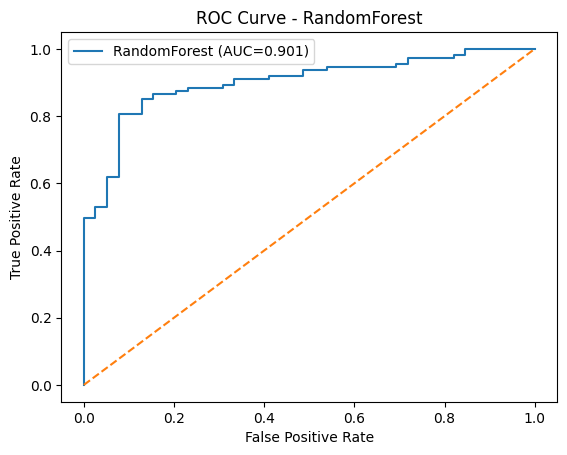

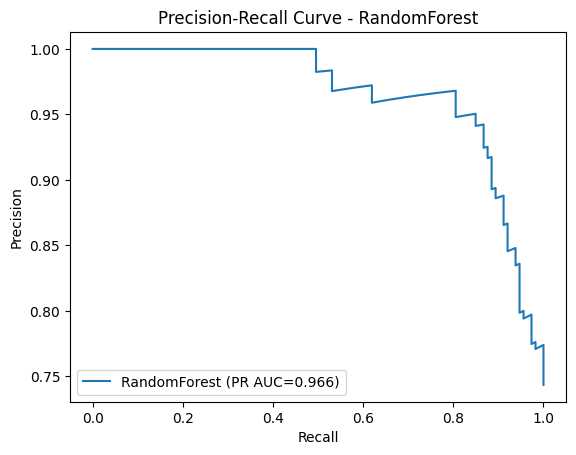


==================== ExtraTrees ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1000
           1       1.00      0.99      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.51      0.61        39
           1       0.85      0.94      0.89       113

    accuracy                           0.83       152
   macro avg       0.79      0.73      0.75       152
weighted avg       0.82      0.83      0.82       152

Training Time: 1.8142 sec
Inference Time: 0.093619 sec
Memory Usage (MB): 1.52
Cohen's Kappa: 0.5014
Brier Score: 0.1038
Confusion Matrix:
 [[ 20  19]
 [  7 106]]


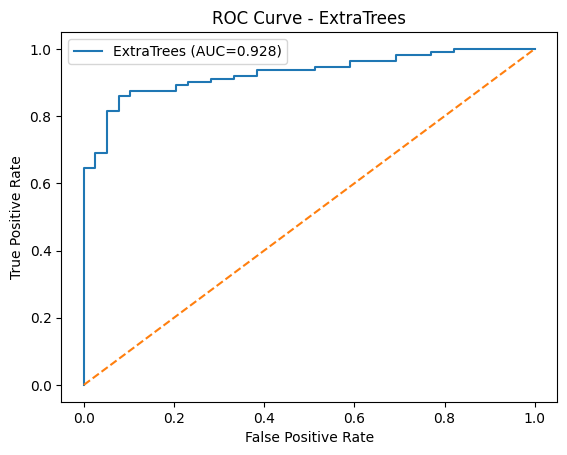

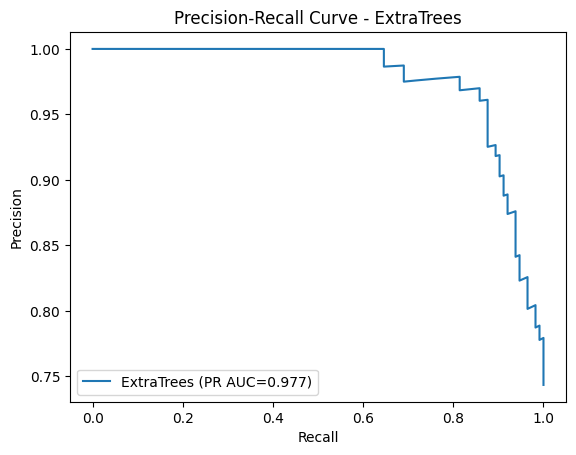


==================== DecisionTree ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.98      0.81      1000
           1       0.97      0.56      0.71      1000

    accuracy                           0.77      2000
   macro avg       0.83      0.77      0.76      2000
weighted avg       0.83      0.77      0.76      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.69      0.66        39
           1       0.89      0.86      0.87       113

    accuracy                           0.82       152
   macro avg       0.76      0.78      0.77       152
weighted avg       0.82      0.82      0.82       152

Training Time: 0.8344 sec
Inference Time: 0.065950 sec
Memory Usage (MB): 1.55
Cohen's Kappa: 0.5328
Brier Score: 0.1669
Confusion Matrix:
 [[27 12]
 [16 97]]


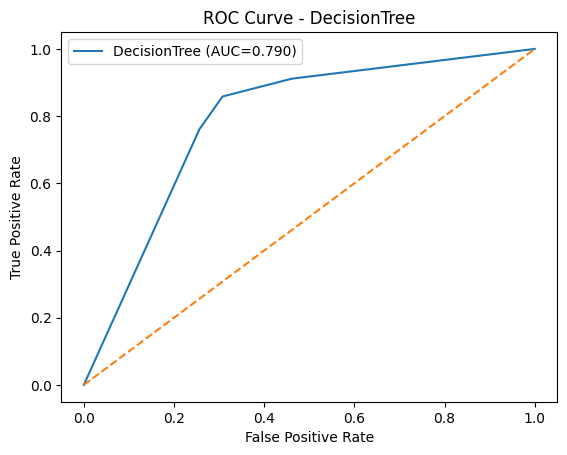

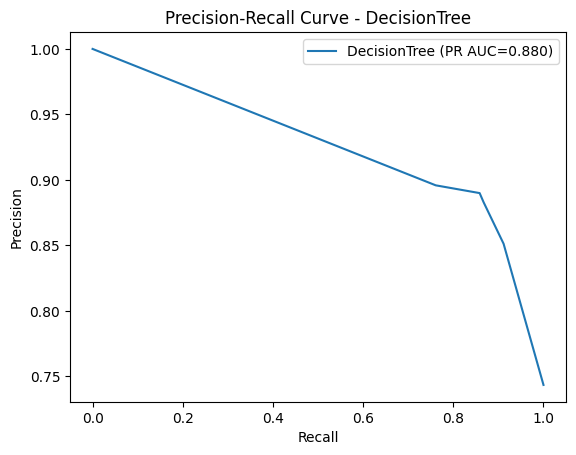


==================== XGBoost ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:27:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.69      0.75        39
           1       0.90      0.95      0.92       113

    accuracy                           0.88       152
   macro avg       0.86      0.82      0.84       152
weighted avg       0.88      0.88      0.88       152

Training Time: 4.1249 sec
Inference Time: 0.026592 sec
Memory Usage (MB): 28.39
Cohen's Kappa: 0.6731
Brier Score: 0.0965
Confusion Matrix:
 [[ 27  12]
 [  6 107]]


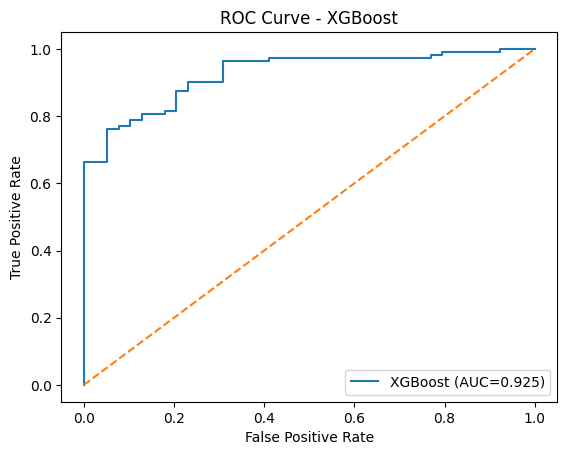

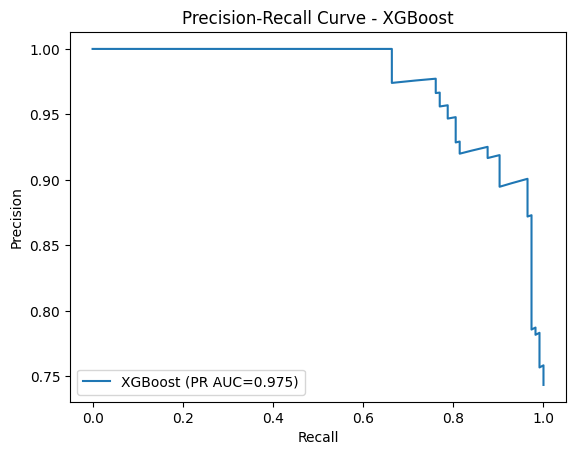


==================== CatBoost ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      1000
           1       0.99      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.49      0.59        39
           1       0.84      0.95      0.89       113

    accuracy                           0.83       152
   macro avg       0.80      0.72      0.74       152
weighted avg       0.82      0.83      0.82       152

Training Time: 92.1146 sec
Inference Time: 0.016441 sec
Memory Usage (MB): -22.72
Cohen's Kappa: 0.4919
Brier Score: 0.1185
Confusion Matrix:
 [[ 19  20]
 [  6 107]]


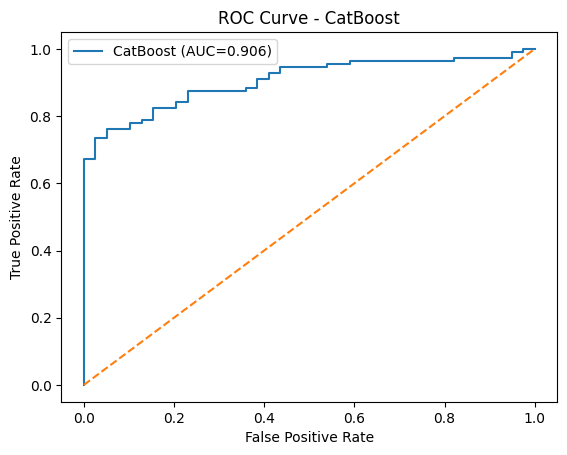

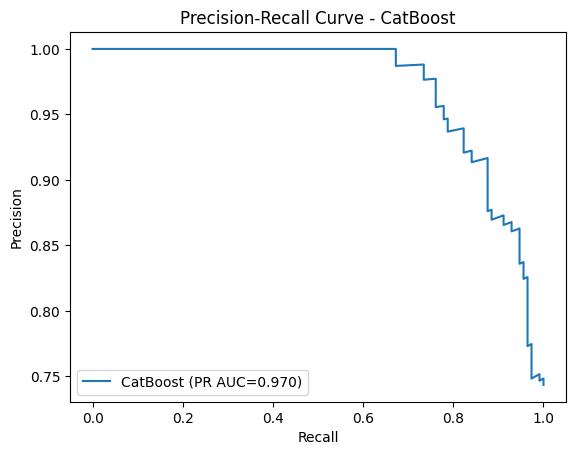

In [95]:
import time
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             brier_score_loss, roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# =========================
# Data
# =========================
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

# =========================
# Models with best params
# =========================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10,
                                           min_samples_split=2, min_samples_leaf=1,
                                           max_features='log2', random_state=42),

    "ExtraTrees": ExtraTreesClassifier(n_estimators=100, max_depth=20,
                                       min_samples_split=5, min_samples_leaf=1,
                                       max_features='sqrt', random_state=42),

    "DecisionTree": DecisionTreeClassifier(max_depth=10, min_samples_split=2,
                                           min_samples_leaf=1, max_features=None,
                                           random_state=42),

    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                             min_child_weight=1, subsample=0.8, colsample_bytree=1.0,
                             use_label_encoder=False, eval_metric='logloss', random_state=42),

    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.01, depth=10,
                                   l2_leaf_reg=1, border_count=64, verbose=0, random_state=42)
}

# =========================
# Evaluation Function
# =========================
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n{'='*20} {name} {'='*20}")

    # Memory before
    process = psutil.Process()
    mem_before = process.memory_info().rss / (1024 * 1024)

    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Memory after
    mem_after = process.memory_info().rss / (1024 * 1024)

    # Inference
    start_time = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    infer_time = time.time() - start_time

    # Reports
    print("Train Classification Report:\n", classification_report(y_train, model.predict(X_train)))
    print("Test Classification Report:\n", classification_report(y_test, y_pred))

    # Metrics
    kappa = cohen_kappa_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_prob[:, 1]) if y_prob is not None and len(np.unique(y_test))==2 else None

    print(f"Training Time: {train_time:.4f} sec")
    print(f"Inference Time: {infer_time:.6f} sec")
    print(f"Memory Usage (MB): {mem_after - mem_before:.2f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    if brier is not None:
        print(f"Brier Score: {brier:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # ROC AUC and Curve
    if y_prob is not None and len(np.unique(y_test))==2:
        roc_auc = roc_auc_score(y_test, y_prob[:, 1])
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        plt.figure()
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
        plt.plot([0,1],[0,1],'--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend()
        plt.show()

        # PR Curve
        precision, recall, _ = precision_recall_curve(y_test, y_prob[:, 1])
        pr_auc = average_precision_score(y_test, y_prob[:, 1])
        plt.figure()
        plt.plot(recall, precision, label=f'{name} (PR AUC={pr_auc:.3f})')
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve - {name}")
        plt.legend()
        plt.show()

# =========================
# Run Evaluation
# =========================
for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)


In [96]:
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, average_precision_score
from sklearn.utils import resample

def bootstrap_ci(model, X_test, y_test, metric_func, n_bootstrap=1000, ci=95, seed=42):
    rng = np.random.RandomState(seed)
    scores = []

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    for i in range(n_bootstrap):
        indices = rng.randint(0, len(y_test), len(y_test))
        y_true_sample = y_test.iloc[indices] if hasattr(y_test, "iloc") else y_test[indices]
        y_pred_sample = y_pred[indices]
        y_prob_sample = y_prob[indices, :] if y_prob is not None else None

        if metric_func.__name__ in ["roc_auc_score", "average_precision_score"] and y_prob_sample is not None:
            score = metric_func(y_true_sample, y_prob_sample[:, 1])
        else:
            score = metric_func(y_true_sample, y_pred_sample)

        scores.append(score)

    lower = np.percentile(scores, (100-ci)/2)
    upper = np.percentile(scores, 100-(100-ci)/2)
    return np.mean(scores), lower, upper


In [97]:
model = models["RandomForest"]
model.fit(X_train, y_train)

acc_mean, acc_low, acc_high = bootstrap_ci(model, X_test, y_test, accuracy_score)
print(f"Accuracy: {acc_mean:.3f} [{acc_low:.3f}, {acc_high:.3f}]")

kappa_mean, kappa_low, kappa_high = bootstrap_ci(model, X_test, y_test, cohen_kappa_score)
print(f"Kappa: {kappa_mean:.3f} [{kappa_low:.3f}, {kappa_high:.3f}]")

roc_mean, roc_low, roc_high = bootstrap_ci(model, X_test, y_test, roc_auc_score)
print(f"ROC AUC: {roc_mean:.3f} [{roc_low:.3f}, {roc_high:.3f}]")

pr_mean, pr_low, pr_high = bootstrap_ci(model, X_test, y_test, average_precision_score)
print(f"PR AUC: {pr_mean:.3f} [{pr_low:.3f}, {pr_high:.3f}]")


Accuracy: 0.823 [0.757, 0.882]
Kappa: 0.467 [0.296, 0.639]
ROC AUC: 0.902 [0.845, 0.950]
PR AUC: 0.966 [0.941, 0.985]


In [98]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n===== {name} - 5-Fold Training Accuracy =====")

    fold_train_acc = []
    fold = 1

    for train_index, _ in skf.split(X_train, y_train):
        X_tr = X_train.iloc[train_index]
        y_tr = y_train.iloc[train_index]

        # Train
        model.fit(X_tr, y_tr)

        # Compute training accuracy on the same fold
        y_tr_pred = model.predict(X_tr)
        acc = accuracy_score(y_tr, y_tr_pred)
        fold_train_acc.append(acc)

        print(f"Fold {fold} Training Accuracy: {acc:.4f}")
        fold += 1

    mean_acc = np.mean(fold_train_acc)
    std_acc = np.std(fold_train_acc)
    print(f"Mean Training Accuracy: {mean_acc:.4f} | Std Dev: {std_acc:.4f}")



===== RandomForest - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.9313
Fold 2 Training Accuracy: 0.8994
Fold 3 Training Accuracy: 0.9250
Fold 4 Training Accuracy: 0.9200
Fold 5 Training Accuracy: 0.9150
Mean Training Accuracy: 0.9181 | Std Dev: 0.0108

===== ExtraTrees - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.9994
Fold 2 Training Accuracy: 0.9956
Fold 3 Training Accuracy: 0.9988
Fold 4 Training Accuracy: 0.9981
Fold 5 Training Accuracy: 0.9988
Mean Training Accuracy: 0.9981 | Std Dev: 0.0013

===== DecisionTree - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.8294
Fold 2 Training Accuracy: 0.8106
Fold 3 Training Accuracy: 0.7725
Fold 4 Training Accuracy: 0.8025
Fold 5 Training Accuracy: 0.8075
Mean Training Accuracy: 0.8045 | Std Dev: 0.0184

===== XGBoost - 5-Fold Training Accuracy =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:30:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 Training Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:30:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 Training Accuracy: 0.9988


...

Fold 3 Training Accuracy: 0.9994


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:30:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4 Training Accuracy: 0.9988


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:30:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 Training Accuracy: 0.9994
Mean Training Accuracy: 0.9992 | Std Dev: 0.0005

===== CatBoost - 5-Fold Training Accuracy =====
Fold 1 Training Accuracy: 0.9975
Fold 2 Training Accuracy: 0.9969
Fold 3 Training Accuracy: 0.9962
Fold 4 Training Accuracy: 0.9969
Fold 5 Training Accuracy: 0.9975
Mean Training Accuracy: 0.9970 | Std Dev: 0.0005


**hybrid model**


==================== RandomForest ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90      1000
           1       1.00      0.77      0.87      1000

    accuracy                           0.88      2000
   macro avg       0.90      0.88      0.88      2000
weighted avg       0.90      0.88      0.88      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.46      0.57        39
           1       0.84      0.95      0.89       113

    accuracy                           0.82       152
   macro avg       0.79      0.70      0.73       152
weighted avg       0.81      0.82      0.81       152

Training Time: 1.2184 sec
Inference Time: 0.027457 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.4673
Brier Score: 0.1159
Confusion Matrix:
 [[ 18  21]
 [  6 107]]


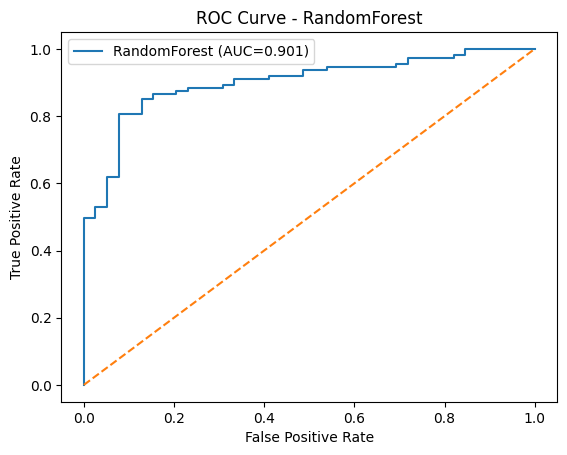

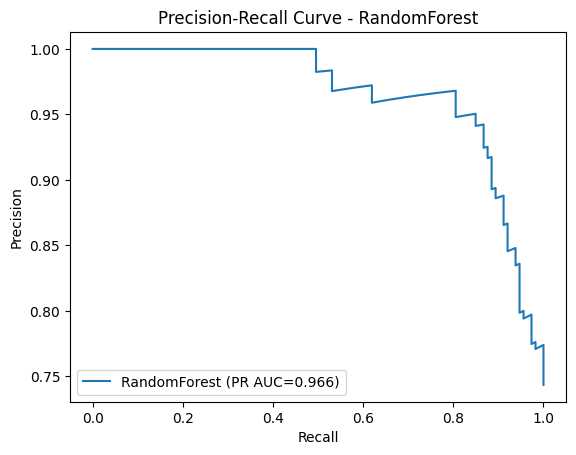


==================== ExtraTrees ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1000
           1       1.00      0.99      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.51      0.61        39
           1       0.85      0.94      0.89       113

    accuracy                           0.83       152
   macro avg       0.79      0.73      0.75       152
weighted avg       0.82      0.83      0.82       152

Training Time: 0.4778 sec
Inference Time: 0.029182 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.5014
Brier Score: 0.1038
Confusion Matrix:
 [[ 20  19]
 [  7 106]]


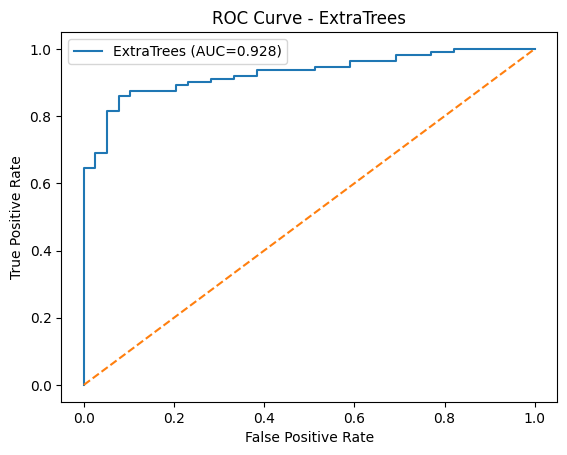

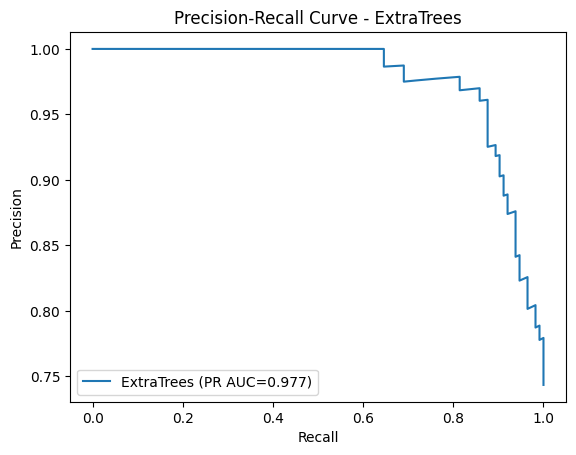


==================== DecisionTree ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.98      0.81      1000
           1       0.97      0.56      0.71      1000

    accuracy                           0.77      2000
   macro avg       0.83      0.77      0.76      2000
weighted avg       0.83      0.77      0.76      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.69      0.66        39
           1       0.89      0.86      0.87       113

    accuracy                           0.82       152
   macro avg       0.76      0.78      0.77       152
weighted avg       0.82      0.82      0.82       152

Training Time: 0.2659 sec
Inference Time: 0.007829 sec
Memory Usage (MB): 0.00
Cohen's Kappa: 0.5328
Brier Score: 0.1669
Confusion Matrix:
 [[27 12]
 [16 97]]


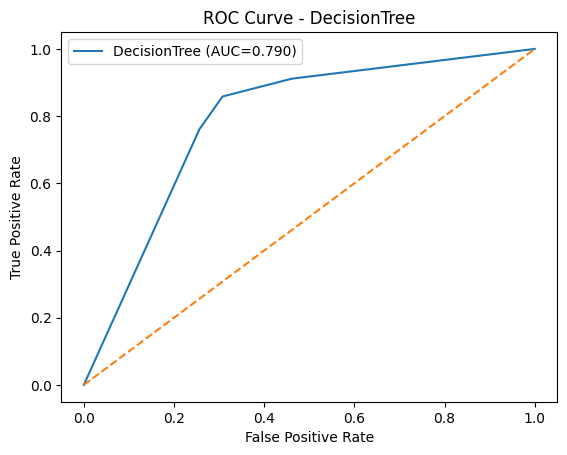

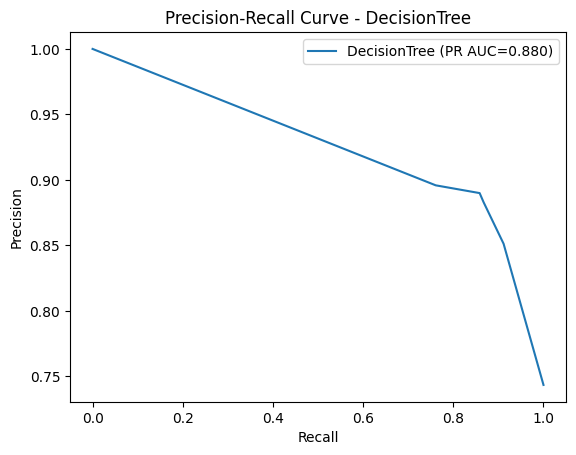


==================== XGBoost ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:34:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.69      0.75        39
           1       0.90      0.95      0.92       113

    accuracy                           0.88       152
   macro avg       0.86      0.82      0.84       152
weighted avg       0.88      0.88      0.88       152

Training Time: 1.7983 sec
Inference Time: 0.012847 sec
Memory Usage (MB): 1.03
Cohen's Kappa: 0.6731
Brier Score: 0.0965
Confusion Matrix:
 [[ 27  12]
 [  6 107]]


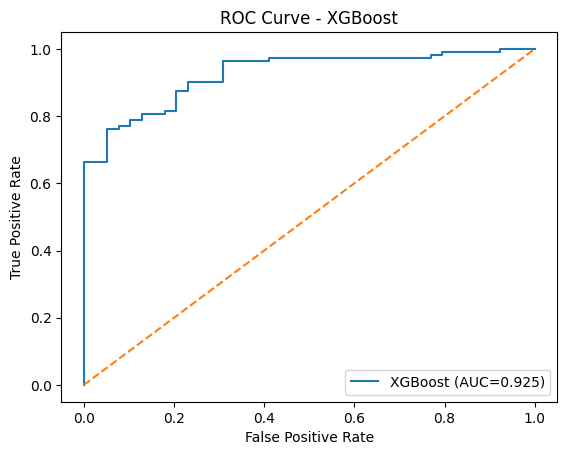

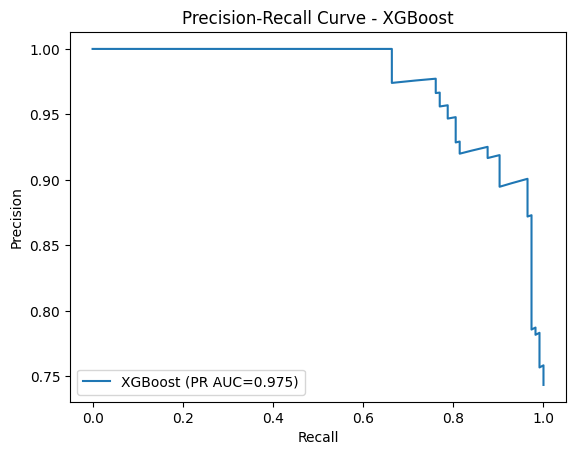


==================== CatBoost ====================
Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      1000
           1       0.99      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.49      0.59        39
           1       0.84      0.95      0.89       113

    accuracy                           0.83       152
   macro avg       0.80      0.72      0.74       152
weighted avg       0.82      0.83      0.82       152

Training Time: 36.8360 sec
Inference Time: 0.006967 sec
Memory Usage (MB): -12.65
Cohen's Kappa: 0.4919
Brier Score: 0.1185
Confusion Matrix:
 [[ 19  20]
 [  6 107]]


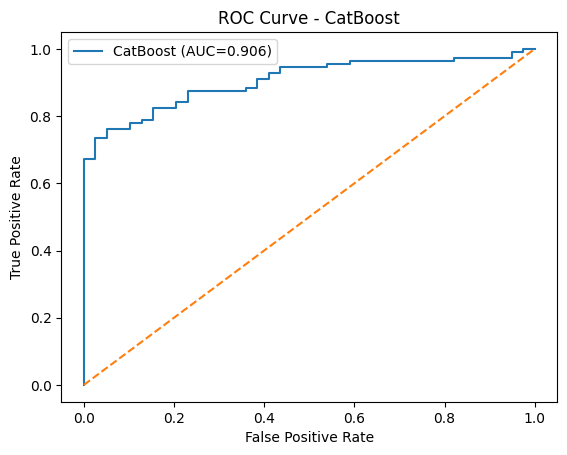

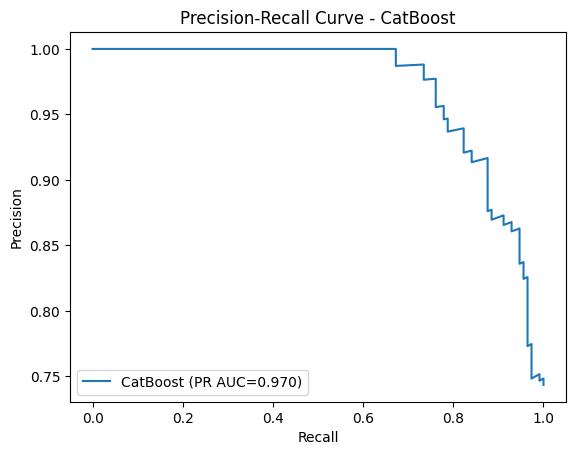


==================== HybridVoting ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:34:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Test Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.56      0.67        39
           1       0.86      0.96      0.91       113

    accuracy                           0.86       152
   macro avg       0.84      0.76      0.79       152
weighted avg       0.85      0.86      0.85       152

Training Time: 39.4379 sec
Inference Time: 0.047260 sec
Memory Usage (MB): 13.49
Cohen's Kappa: 0.5781
Brier Score: 0.1063
Confusion Matrix:
 [[ 22  17]
 [  5 108]]


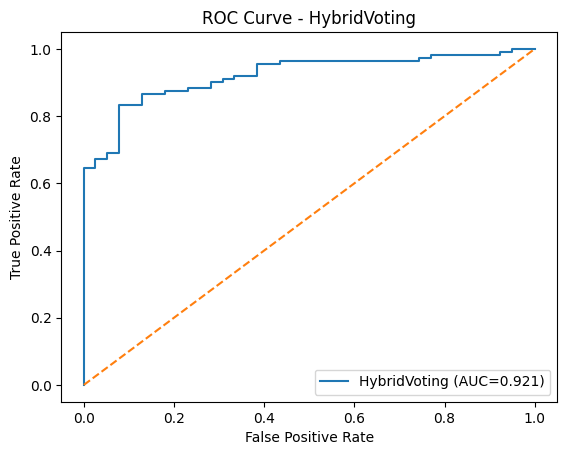

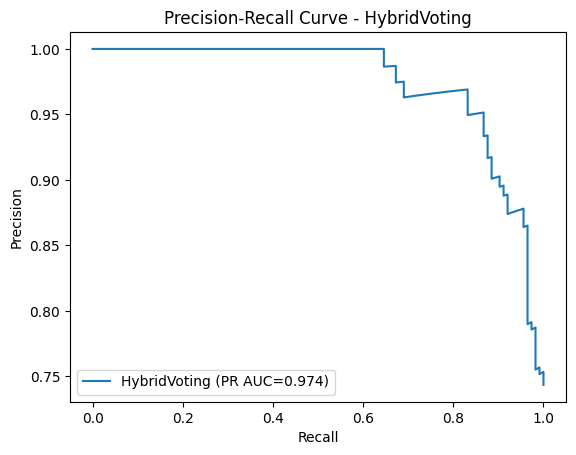

In [99]:
from sklearn.ensemble import VotingClassifier

# =========================
# Hybrid Voting Classifier
# =========================
voting_model = VotingClassifier(
    estimators=[
        ('rf', models['RandomForest']),
        ('xgb', models['XGBoost']),
        ('cat', models['CatBoost'])
    ],
    voting='soft'
)

models["HybridVoting"] = voting_model

# =========================
# Run Evaluation (including hybrid)
# =========================
for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)


In [100]:
!pip install SALib


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:35:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 10 important features:
                        feature  importance
71          tqwt_TKEO_std_dec_7    0.272932
74         tqwt_TKEO_std_dec_12    0.271739
99    tqwt_kurtosisValue_dec_27    0.258375
13   std_delta_delta_log_energy    0.243265
8                 std_7th_delta    0.227580
50  tqwt_entropy_shannon_dec_13    0.225075
6          std_delta_log_energy    0.218428
92         tqwt_maxValue_dec_10    0.195485
97    tqwt_kurtosisValue_dec_18    0.193219
12               std_11th_delta    0.191359


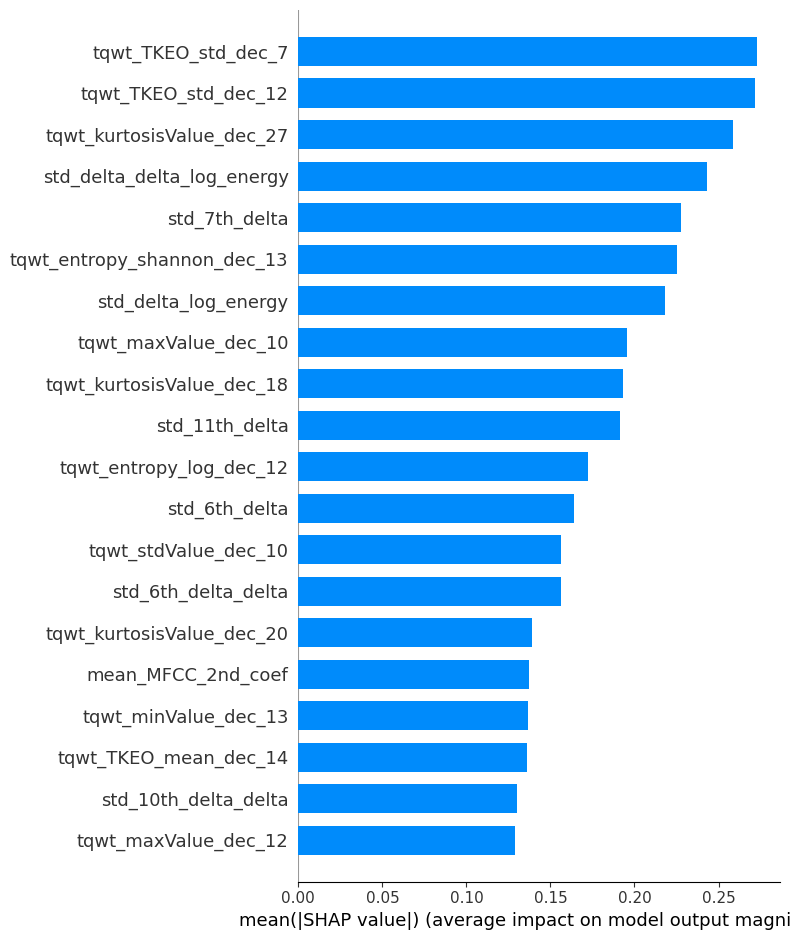

In [101]:
import shap


X = train_df.drop('class', axis=1)
y = train_df['class']


from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X, y)


explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)


shap_importance = np.abs(shap_values).mean(axis=0)


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False)

print("Top 10 important features:")
print(feature_importance.head(10))


shap.summary_plot(shap_values, X, plot_type="bar")


In [102]:
pip install lime

In [103]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd


X = train_df.drop('class', axis=1)
y = train_df['class']


from xgboost import XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X, y)


explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns,
    class_names=['Class 0', 'Class 1'],
    mode='classification'
)


sample_idx = [0, 1, 2]
for idx in sample_idx:
    sample = X.iloc[idx].values.reshape(1, -1)

    # Explain instance
    exp = explainer.explain_instance(
        data_row=sample[0],
        predict_fn=xgb_model.predict_proba,
        num_features=10
    )

    print(f"\nLIME explanation for sample {idx}:")
    exp.show_in_notebook(show_table=True, show_all=False)

    print(exp.as_list())


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:35:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



LIME explanation for sample 0:


[('std_delta_delta_log_energy <= -0.65', -0.09786121414203798), ('-0.36 < tqwt_kurtosisValue_dec_27 <= -0.25', 0.09211527045078749), ('-0.58 < std_7th_delta <= 0.82', -0.04664269629688938), ('app_det_TKEO_mean_4_coef <= -0.56', -0.04038635794286717), ('-0.55 < tqwt_stdValue_dec_16 <= -0.44', -0.0354216746047618), ('tqwt_TKEO_std_dec_12 > 0.67', -0.03505904495406226), ('-0.39 < tqwt_entropy_shannon_dec_13 <= -0.32', -0.03372397557252334), ('-0.59 < std_11th_delta <= -0.27', -0.03294544319058969), ('0.65 < tqwt_energy_dec_11 <= 0.68', 0.032700153661405086), ('0.65 < tqwt_energy_dec_12 <= 0.68', -0.030142499550608926)]

LIME explanation for sample 1:


[('std_7th_delta > 0.82', 0.1326473345983508), ('std_delta_delta_log_energy <= -0.65', -0.08443041715531356), ('std_6th_delta > 0.65', -0.0547324947951254), ('DFA <= -0.95', -0.04988896759056389), ('tqwt_TKEO_mean_dec_14 <= -1.47', 0.04687900173423872), ('tqwt_entropy_shannon_dec_7 > -0.37', -0.04348529897379003), ('app_TKEO_std_7_coef > 0.37', -0.039940468091422994), ('tqwt_TKEO_std_dec_13 <= -1.50', -0.03799181473056851), ('tqwt_TKEO_std_dec_12 <= -1.52', 0.03528642863687766), ('-0.73 < tqwt_stdValue_dec_13 <= -0.23', -0.026454007067573438)]

LIME explanation for sample 2:


[('std_delta_delta_log_energy <= -0.65', -0.07622636052064236), ('tqwt_minValue_dec_10 > 0.53', 0.05796417235094436), ('std_11th_delta <= -0.59', -0.05014472619418502), ('0.65 < tqwt_TKEO_std_dec_12 <= 0.67', -0.049434623663786786), ('-0.68 < std_7th_delta <= -0.58', -0.04219596193927911), ('-0.37 < tqwt_entropy_shannon_dec_7 <= -0.37', -0.041687532185955396), ('tqwt_TKEO_mean_dec_14 > 0.67', -0.04101426422496616), ('tqwt_TKEO_mean_dec_13 > 0.43', 0.03811933645180779), ('0.66 < tqwt_TKEO_std_dec_13 <= 0.67', 0.03743015247011674), ('tqwt_stdValue_dec_16 <= -0.55', -0.032206759941351616)]


In [104]:
from sklearn.inspection import permutation_importance


xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)


perm_importance = permutation_importance(
    xgb_model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc'
)


perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("Top 10 Permutation Importance Features:")
print(perm_df.head(10))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:35:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Top 10 Permutation Importance Features:
                       feature  importance_mean  importance_std
0                          DFA         0.022986        0.009341
13  std_delta_delta_log_energy         0.013887        0.004987
98   tqwt_kurtosisValue_dec_20         0.012457        0.003294
47  tqwt_entropy_shannon_dec_7         0.010188        0.004506
8                std_7th_delta         0.009145        0.008127
93        tqwt_maxValue_dec_11         0.008850        0.003353
14         std_6th_delta_delta         0.006422        0.006476
86        tqwt_stdValue_dec_16         0.006308        0.003310
1                 minIntensity         0.005741        0.002883
97   tqwt_kurtosisValue_dec_18         0.004969        0.003906


In [105]:
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
import numpy as np


problem = {
    'num_vars': X_train.shape[1],
    'names': list(X_train.columns),
    'bounds': [[X_train[col].min(), X_train[col].max()] for col in X_train.columns]
}


param_values = morris_sample.sample(problem, N=1000, num_levels=4)


Y = np.array([xgb_model.predict_proba(param.reshape(1, -1))[:,1][0] for param in param_values], dtype=float)

# Perform Morris analysis
morris_results = morris_analyze.analyze(
    problem, param_values, Y, conf_level=0.95, print_to_console=False, num_levels=4
)

# Extract results
morris_df = pd.DataFrame({
    'feature': X_train.columns,
    'mu_star': morris_results['mu_star'],
    'sigma': morris_results['sigma']
}).sort_values(by='mu_star', ascending=False)

print("Top 10 Morris Important Features:")
print(morris_df.head(10))


Top 10 Morris Important Features:
                       feature   mu_star     sigma
8                std_7th_delta  0.265232  0.228465
6         std_delta_log_energy  0.184632  0.208917
4           mean_MFCC_2nd_coef  0.166648  0.180495
14         std_6th_delta_delta  0.150124  0.186970
97   tqwt_kurtosisValue_dec_18  0.146716  0.183259
47  tqwt_entropy_shannon_dec_7  0.122567  0.195100
74        tqwt_TKEO_std_dec_12  0.119655  0.165076
59     tqwt_entropy_log_dec_12  0.118647  0.160301
15         std_7th_delta_delta  0.109407  0.142071
94        tqwt_maxValue_dec_12  0.098437  0.105243
